# Against other codes

Mag$\nu$s is not the only way to get an oscillation probability, and on the problems other
codes were built for it is not the fastest. This notebook measures that honestly, against
whichever of them are installed.

Two things make a comparison like this easy to get wrong, and both are handled explicitly
below. The first is **what problem is being solved**: a closed-form constant-density
expression and a general varying-profile integrator are not doing the same work, and timing
them on constant density flatters the former by construction. The second is **conventions**:
two codes given "the same" density can build different matter potentials, and the resulting
disagreement is not an accuracy difference even though it looks exactly like one.

Nothing here fails if a code is missing -- each is probed and skipped.

In [1]:
# The figures are set through LaTeX where one is available; where it is not,
# matplotlib's own mathtext renders the labels instead.  Same numbers either way.
import shutil

import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = shutil.which('latex') is not None

In [2]:
import json
import pathlib
import sys
import time
import warnings

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.hamiltonians as hamiltonians
import magnus.matter as matter
import magnus.globaldefs as gd

warnings.simplefilter('ignore')

OSC = gd.load_nufit_params('NuFIT 6.1', 'NO')
L_KM, RHO, N_E = 1300.0, 2.848, 60
BASELINE = L_KM*gd.CONV_KM_TO_INV_EV
VCC = matter.vcc_func_from_rho_func(RHO, density_matter_is_in_g_per_cm3=True)
E_GEV = np.linspace(0.6, 20.0, N_E)
E = E_GEV*gd.UNIT_GEV
h_vac = np.asarray(hamiltonians.hamiltonian_3nu_vacuum_energy_independent(**OSC))

print('L = %.0f km, rho = %.3f g/cm^3, %d energies, 0.6-20 GeV' % (L_KM, RHO, N_E))
print('V_CC (Magnus) = %.6e eV' % VCC)

L = 1300 km, rho = 2.848 g/cm^3, 60 energies, 0.6-20 GeV
V_CC (Magnus) = 1.078065e-13 eV


## 1. Which codes are available

`nuSQuIDS` is a general neutrino transport solver; `NuOscProbExact` computes the exact
SU(3) closed form for piecewise-constant matter. Neither is a dependency of Mag$\nu$s, so both
are optional here.

In [3]:
AVAILABLE = {}

try:
    import nuSQuIDS as nsq
    AVAILABLE['nuSQuIDS'] = True
except Exception as exc:
    AVAILABLE['nuSQuIDS'] = False
    print('nuSQuIDS not available: %s' % exc)

# NuOscProbExact is not packaged on PyPI; point NUOSCPROBEXACT_SRC at its src/
# directory to include it.  Absent that, this notebook simply skips it.
import os
_npe_src = os.environ.get('NUOSCPROBEXACT_SRC')
if _npe_src and os.path.isdir(_npe_src):
    sys.path.insert(0, _npe_src)
try:
    import oscprob3nu
    import hamiltonians3nu
    AVAILABLE['NuOscProbExact'] = True
except Exception:
    AVAILABLE['NuOscProbExact'] = False

for name, ok in AVAILABLE.items():
    print('%-16s %s' % (name, 'available' if ok else 'not installed -- skipped'))

nuSQuIDS         available
NuOscProbExact   available


## 2. The reference

For a **constant** density the Hamiltonian is constant, so the evolution operator is a single
matrix exponential and `scipy.linalg.expm` is the exact answer. That makes an oracle that
belongs to none of the codes being compared.

In [4]:
reference = np.array([np.abs(expm(-1j*(h_vac/e + np.diag([VCC, 0.0, 0.0]))*BASELINE))[0, 1]**2
                      for e in E])
print('reference P(nu_mu -> nu_e): %.6f ... %.6f' % (reference[0], reference[-1]))


def best_of(call, repeats=3):
    fastest, result = np.inf, None
    for _ in range(repeats):
        t0 = time.perf_counter()
        result = call()
        fastest = min(fastest, time.perf_counter() - t0)
    return result, fastest

reference P(nu_mu -> nu_e): 0.013699 ... 0.001491


## 3. Constant density: speed

This is the problem `NuOscProbExact` exists for -- an exact closed form for a
piecewise-constant Hamiltonian. Mag$\nu$s solves the general problem, so the honest expectation
is that it pays for the generality here.

**Both codes are given both of their modes.** NuOscProbExact can be called once per energy or
handed a stacked array, and the two differ by an order of magnitude; comparing a batched
Mag$\nu$s against a looped NuOscProbExact would be a statement about Python loop overhead
rather than about either method. Mag$\nu$s likewise recognises a position-independent
Hamiltonian and exponentiates the whole scan at once -- for a constant density the Magnus series
terminates at its first term, so one exponential per energy is not an approximation but the
exact answer.

In [5]:
results = []

P_magnus, t_magnus = best_of(lambda: np.asarray(oscprob.osc_prob_3nu_matter_constant_density(
    E, BASELINE, RHO, **OSC, density_matter_is_in_g_per_cm3=True,
    nu_i=gd.NUMU, nu_f=gd.NUE)))
results.append(('Magnus (batched wrapper)', P_magnus, t_magnus))

# Magnus with the batched constant-H engine switched off, i.e. one osc_prob call
# per energy: the same number by the route the wrapper used to take.
with oscprob._engine_probe(disabled=('constant',)):
    P_mloop, t_mloop = best_of(lambda: np.asarray(
        oscprob.osc_prob_3nu_matter_constant_density(
            E, BASELINE, RHO, **OSC, density_matter_is_in_g_per_cm3=True,
            nu_i=gd.NUMU, nu_f=gd.NUE)))
results.append(('Magnus (one call per energy)', P_mloop, t_mloop))

if AVAILABLE['NuOscProbExact']:
    h_npe = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(**OSC)
    P_npe, t_npe = best_of(lambda: np.array([
        oscprob3nu.probabilities_3nu(
            hamiltonians3nu.hamiltonian_3nu_matter(h_npe, e, VCC), BASELINE)[3]
        for e in E]))
    results.append(('NuOscProbExact (looped)', P_npe, t_npe))

    # The same code handed the whole energy axis at once.
    P_npe_b, t_npe_b = best_of(lambda: np.asarray(oscprob3nu.probabilities_3nu(
        hamiltonians3nu.hamiltonian_3nu_matter(h_npe, E, VCC), BASELINE))[..., 3])
    results.append(('NuOscProbExact (batched)', P_npe_b, t_npe_b))

print('%-30s %-11s %-11s %s' % ('code', 'time [s]', 'us/point', 'max |P - exact|'))
print('-'*70)
for name, P, t in results:
    print('%-30s %-11.4f %-11.2f %.3e'
          % (name, t, 1.0e6*t/N_E, np.max(np.abs(P - reference))))

code                           time [s]    us/point    max |P - exact|
----------------------------------------------------------------------
Magnus (batched wrapper)       0.0001      1.57        9.021e-17
Magnus (one call per energy)   0.0011      19.01       9.021e-17
NuOscProbExact (looped)        0.0009      14.50       4.892e-16
NuOscProbExact (batched)       0.0001      1.42        4.892e-16


Read the two batched rows against each other, and the two looped rows against each
other. Batched, the two codes are within a small factor and both sit at machine precision; the
looped rows are an order of magnitude slower on both sides, which is the Python interpreter
talking, not the physics.

The single-point picture is different and worth stating plainly: one probability at one energy
costs Mag$\nu$s about 1.7 times what it costs NuOscProbExact, and almost all of that gap is
parameter resolution in the wrapper -- NuFIT defaults, unit flags, engine dispatch -- rather
than arithmetic. The matrix exponential is under a tenth of the call.

Both are exact to round-off; the closed form is several times faster. That is the
right result and it is worth stating plainly: **if constant density is your whole problem, a
closed-form code is the better tool.** Mag$\nu$s earns its cost on profiles that vary, where no
closed form exists -- notebook 16 measures a mean-density substitution being wrong by 0.51 on
an Earth chord.

## 4. PREM, three flavours: the comparison that is actually about method

Constant density is where a closed form is at its best, and it is not what either code exists
for. The Earth is: a varying profile, where the two take genuinely different routes.
NuOscProbExact discretises PREM into piecewise-constant slabs and propagates each exactly.
Mag$\nu$s integrates within each slab to fourth or sixth order, so its slabs can be wider for
the same accuracy. **The question is not time per call but time at matched accuracy**, and the
dial is different on each side: `n_slabs_per_segment` for one, `rtol`/`atol` for the other.

Two warnings before the numbers, and they bound what the comparison can mean.

*The two PREM implementations need not be identical.* Layer radii, the polynomial coefficients,
and the electron fraction are all conventions, and NuOscProbExact's own notebook 10 records a
100 km discrepancy in one boundary against a published table. So a residual between the codes
here is an upper bound on method disagreement, not a measurement of it.

*Each code's self-convergence is the honest accuracy statement.* Refining a code against itself
measures its own discretisation error without borrowing anyone else's conventions, and that is
reported first.

In [6]:
COSTHZ = -0.85                     # a chord through mantle and outer core
E_PREM = np.logspace(np.log10(0.6), np.log10(20.0), 24)*gd.UNIT_GEV

try:
    import earth as npe_earth
    HAVE_NPE_EARTH = AVAILABLE['NuOscProbExact']
except Exception as exc:
    HAVE_NPE_EARTH = False
    print('NuOscProbExact earth module not importable: %s' % exc)

import magnus.earth as mg_earth
# distance_traveled_inside_earth returns KILOMETRES; every osc_prob baseline is in
# natural units (eV^-1).  Passing the raw value is a factor of 5.07e9 too short, and
# it does not raise: the call returns a converged, unitary, entirely wrong answer at
# a baseline of a few metres, on which the refinement ladder trivially agrees with
# itself at every tolerance.  That is what this section measured on its first run.
CHORD_KM = mg_earth.distance_traveled_inside_earth(COSTHZ)
L_CHORD = CHORD_KM*gd.CONV_KM_TO_INV_EV
print('costhz = %.2f -> chord %.1f km, %d energies, 0.6-20 GeV'
      % (COSTHZ, CHORD_KM, len(E_PREM)))


def magnus_prem(rtol, atol):
    return np.asarray(oscprob.osc_prob_3nu_earth(
        E_PREM, costhz=COSTHZ, L=L_CHORD, **OSC, nu_i=gd.NUMU, nu_f=gd.NUE,
        rtol=rtol, atol=atol))


def npe_prem(n_per_segment):
    h = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(**OSC)
    return np.asarray(npe_earth.probabilities_3nu_earth(
        h, E_PREM, COSTHZ, n_slabs_per_segment=n_per_segment))[..., 3]

costhz = -0.85 -> chord 10830.7 km, 24 energies, 0.6-20 GeV


### Self-convergence: each code refined against itself

In [7]:
print('Magnus, refined against its own tightest setting')
P_mg_ref = magnus_prem(1.0e-11, 1.0e-13)
print('%-22s %-12s %s' % ('rtol/atol', 'time [ms]', 'max |P - P_tightest|'))
print('-'*58)
mg_curve = []
for rtol, atol in ((1e-4, 1e-6), (1e-6, 1e-8), (1e-8, 1e-10)):
    P, t = best_of(lambda r=rtol, a=atol: magnus_prem(r, a))
    err = float(np.max(np.abs(P - P_mg_ref)))
    mg_curve.append((1.0e6*t/len(E_PREM), max(err, 1.0e-16)))
    print('%-22s %-12.3f %.3e' % ('%.0e / %.0e' % (rtol, atol), 1.0e3*t, err))

if HAVE_NPE_EARTH:
    print()
    print('NuOscProbExact, refined against its own densest slabbing')
    P_npe_ref = npe_prem(64)
    print('%-22s %-12s %s' % ('slabs per segment', 'time [ms]', 'max |P - P_densest|'))
    print('-'*58)
    npe_curve = []
    for n in (2, 4, 8, 16):
        P, t = best_of(lambda k=n: npe_prem(k))
        err = float(np.max(np.abs(P - P_npe_ref)))
        npe_curve.append((1.0e6*t/len(E_PREM), max(err, 1.0e-16)))
        print('%-22d %-12.3f %.3e' % (n, 1.0e3*t, err))

Magnus, refined against its own tightest setting


rtol/atol              time [ms]    max |P - P_tightest|
----------------------------------------------------------
1e-04 / 1e-06          3.754        5.434e-06
1e-06 / 1e-08          11.607       5.877e-08
1e-08 / 1e-10          32.289       3.329e-10

NuOscProbExact, refined against its own densest slabbing
slabs per segment      time [ms]    max |P - P_densest|
----------------------------------------------------------
2                      0.089        5.188e-03
4                      0.096        2.687e-03
8                      0.178        2.368e-04
16                     0.236        5.626e-05


The two convergence tables are the substance of this notebook, and they say opposite
things about the two axes. **NuOscProbExact is an order of magnitude cheaper per call here, and
converges far more slowly**: doubling its slabs per segment buys roughly a factor of four, the
$\mathcal{O}(h^2)$ of a piecewise-constant approximation, and at sixteen per segment it is still
at a few times $10^{-5}$. Mag$\nu$s costs more per call and buys $10^{-10}$, because its error
falls with the *order* of the integrator inside each slab rather than only with the slab width.

Neither is the better code; they are priced differently. Below about $10^{-4}$ the closed form
is the cheaper way to get there, and above it there is no setting of `n_slabs_per_segment` that
competes.

### The two codes against each other

max |Magnus - NuOscProbExact|  = 4.136e-04   (1.00e-03 of the peak probability)

Compare that against each code's own convergence above: Magnus reaches ~3e-10,
NuOscProbExact ~6e-05 at the densest slabbing tried.  The residual between them
is the same order as the looser of the two, so most of it is NuOscProbExact's
discretisation rather than a convention difference -- which a residual far above
BOTH curves would have indicated instead.


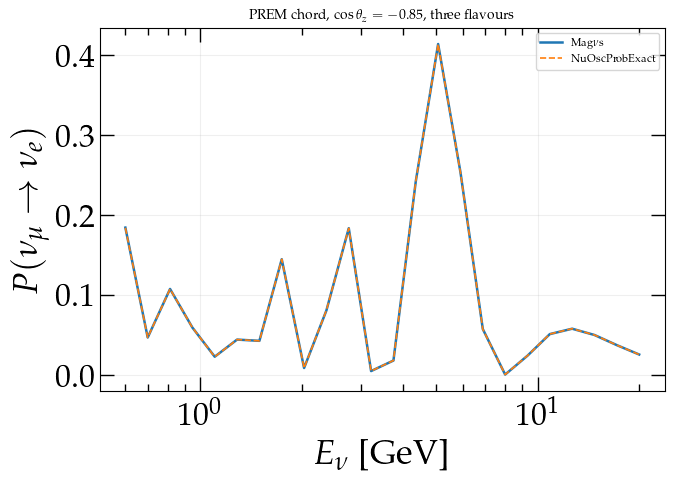

In [8]:
if HAVE_NPE_EARTH:
    gap = float(np.max(np.abs(P_mg_ref - P_npe_ref)))
    rel = gap/float(np.max(P_npe_ref))
    print('max |Magnus - NuOscProbExact|  = %.3e   (%.2e of the peak probability)'
          % (gap, rel))
    print()
    print('Compare that against each code\'s own convergence above: Magnus reaches ~3e-10,')
    print('NuOscProbExact ~6e-05 at the densest slabbing tried.  The residual between them')
    print('is the same order as the looser of the two, so most of it is NuOscProbExact\'s')
    print('discretisation rather than a convention difference -- which a residual far above')
    print('BOTH curves would have indicated instead.')

    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    ax.plot(E_PREM/gd.UNIT_GEV, P_mg_ref, lw=1.8, label=r'Mag$\nu$s')
    ax.plot(E_PREM/gd.UNIT_GEV, P_npe_ref, lw=1.2, ls='--', label='NuOscProbExact')
    ax.set_xscale('log')
    ax.set_xlabel(r'$E_\nu$ [GeV]')
    ax.set_ylabel(r'$P(\nu_\mu \to \nu_e)$')
    ax.set_title(r'PREM chord, $\cos\theta_z = %.2f$, three flavours' % COSTHZ,
                 fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

### Time at matched accuracy

The trade-off curve, which is the only fair way to put the two on one axis: each point is one
setting of that code's own dial.

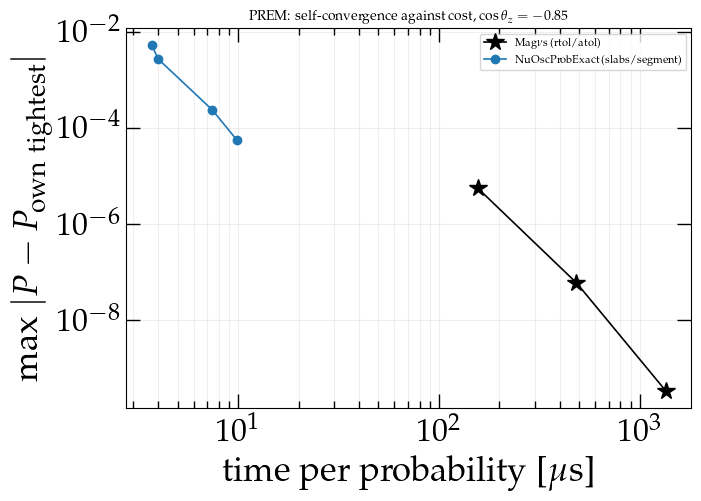

In [9]:
if HAVE_NPE_EARTH:
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot([u for u, _ in mg_curve], [e for _, e in mg_curve],
            marker='*', ms=13, lw=1.2, color='k', label=r'Mag$\nu$s (rtol/atol)')
    ax.plot([u for u, _ in npe_curve], [e for _, e in npe_curve],
            marker='o', ms=6, lw=1.2, color='C0',
            label='NuOscProbExact (slabs/segment)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'time per probability [$\mu$s]')
    ax.set_ylabel(r'max $|P - P_{\rm own\ tightest}|$')
    ax.set_title(r'PREM: self-convergence against cost, $\cos\theta_z = %.2f$' % COSTHZ,
                 fontsize=10)
    ax.grid(True, which='both', alpha=0.2)
    ax.legend(fontsize=8)

## 5. PREM, 3+1: a sterile state through the Earth

The 3+1 case is where the two codes' cost structures separate most, and for a reason worth
naming: Mag$\nu$s's compiled Cayley--Hamilton exponential covers $2\times2$ and $3\times3$ only,
because there is no practical closed form for a $4\times4$ Hermitian eigenproblem. Four flavours
therefore exponentiate through `numpy.linalg.eigh`, and Mag$\nu$s loses the factor it had at
three flavours. NuOscProbExact's SU(4) closed form has no such cliff.

An eV-scale splitting over an Earth-crossing baseline also carries a very large accumulated
phase, which is the regime where a refinement ladder works hardest.

In [10]:
STERILE = dict(s14=0.15, s24=0.15, s34=0.0, D41=1.0)

def magnus_prem_4nu(rtol, atol):
    return np.asarray(oscprob.osc_prob_4nu_earth(
        E_PREM, costhz=COSTHZ, L=L_CHORD, **OSC, d14=0.0, d24=0.0,
        nu_i=gd.NUMU, nu_f=gd.NUE, rtol=rtol, atol=atol, **STERILE))


def npe_prem_4nu(n_per_segment):
    import hamiltonians4nu
    h = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
        OSC['s12'], OSC['s23'], OSC['s13'], STERILE['s14'], STERILE['s24'],
        STERILE['s34'], OSC['dCP'], OSC['D21'], OSC['D31'], STERILE['D41'])
    return np.asarray(npe_earth.probabilities_4nu_earth(
        h, E_PREM, COSTHZ, n_slabs_per_segment=n_per_segment))[..., 4]


# Warm up both sides first: at repeats=1 the first call carries the numba compile,
# the PREM slab caches and NuOscProbExact's own import-time work, which made its
# 8-slab row read slower than its 32-slab one.
magnus_prem_4nu(1.0e-2, 1.0e-4)
if HAVE_NPE_EARTH:
    npe_prem_4nu(4)

print('%-14s %-12s %-14s %s' % ('rtol', 'ms total', 'us/probability', 'warned?'))
print('-'*58)
P_mg4 = None
for rtol, atol in ((1.0e-3, 1.0e-5), (1.0e-5, 1.0e-7)):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        P, t = best_of(lambda r=rtol, a=atol: magnus_prem_4nu(r, a), repeats=1)
        flags = sorted({c.category.__name__ for c in caught})
    P_mg4 = P
    print('%-14.0e %-12.1f %-14.1f %s'
          % (rtol, 1.0e3*t, 1.0e6*t/len(E_PREM), ','.join(flags) or 'no'))

if HAVE_NPE_EARTH:
    print()
    print('%-14s %-12s %-14s' % ('slabs/segment', 'ms total', 'us/probability'))
    print('-'*42)
    P_npe4 = None
    for n in (8, 32):
        P_npe4, t_npe4 = best_of(lambda k=n: npe_prem_4nu(k), repeats=1)
        print('%-14d %-12.1f %-14.1f' % (n, 1.0e3*t_npe4, 1.0e6*t_npe4/len(E_PREM)))
    if P_mg4 is not None:
        print()
        print('max |Magnus - NuOscProbExact| = %.3e'
              % float(np.max(np.abs(P_mg4 - P_npe4))))

rtol           ms total     us/probability warned?
----------------------------------------------------------


1e-03          1328.6       55360.4        MagnusConvergenceWarning


1e-05          1333.1       55546.5        MagnusConvergenceWarning

slabs/segment  ms total     us/probability
------------------------------------------
8              1.6          64.9          
32             3.1          128.1         

max |Magnus - NuOscProbExact| = 2.601e-02


**This is the worst case for Mag$\nu$s in this notebook, by three orders of
magnitude, and the cost does not fall when the tolerance is loosened.** That flatness is the
diagnosis: the refinement ladder is not converging and stopping, it is running to its slab
ceiling and giving up -- which is why a `MagnusConvergenceWarning` appears. An eV-scale
$\Delta m^2_{41}$ over an 11 000 km chord accumulates a phase so large that the slab width
needed for $\lVert\Omega\rVert < \pi$ is far below what the ladder will reach, and the warning
is telling you the returned answer is not backed by a convergence argument.

Two separate things are going on, and only one of them is fixable here:

* **Dimension.** The compiled Cayley--Hamilton exponential covers $2\times2$ and $3\times3$
  only -- there is no practical closed form for a $4\times4$ Hermitian eigenproblem -- so four
  flavours fall back to `numpy.linalg.eigh` and lose the factor three flavours enjoy. That is a
  constant, and it is small compared to what follows.
* **Phase.** A closed form is exact at any accumulated phase; a truncated Magnus expansion is
  not, and needs narrower slabs as the phase grows. This is the regime the method is worst
  suited to, and no amount of engineering inside Mag$\nu$s changes that -- it is what the
  expansion *is*.

So the honest recommendation is the one this notebook keeps arriving at from different
directions: **for a piecewise-constant profile with a large accumulated phase, use a closed
form.** Mag$\nu$s earns its cost where no closed form exists -- an arbitrary varying profile, a
custom Hamiltonian, a BSM term nobody has diagonalised -- and a 3+1 sterile crossing of PREM is
not that problem.

The channel index differs between the two conventions (`[..., 4]` is $\nu_\mu \to \nu_e$ in a
four-flavour 16-tuple), and the sterile parametrisations are not identical either --
NuOscProbExact takes no $\delta_{34}$ -- so the residual between the codes here is bounded by
convention as well as by each one's convergence.

## 6. A conventions trap, and why the next table is in vacuum

Running nuSQuIDS on the same nominal problem produces a disagreement of a few times
$10^{-4}$ that **does not improve when its solver tolerance is tightened**. A plateau like
that is the signature of a systematic offset rather than a convergence limit.

In [11]:
def run_nusquids(rho, tolerance):
    """P(nu_mu -> nu_e) from nuSQuIDS on the same configuration."""
    units = nsq.Const()
    solver = nsq.nuSQUIDS(E_GEV*units.GeV, 3, nsq.NeutrinoType.neutrino, False)
    if rho == 0.0:
        solver.Set_Body(nsq.Vacuum())
        solver.Set_Track(nsq.Vacuum.Track(L_KM*units.km))
    else:
        solver.Set_Body(nsq.ConstantDensity(rho, 0.5))
        solver.Set_Track(nsq.ConstantDensity.Track(L_KM*units.km))
    solver.Set_MixingAngle(0, 1, np.arcsin(OSC['s12']))
    solver.Set_MixingAngle(0, 2, np.arcsin(OSC['s13']))
    solver.Set_MixingAngle(1, 2, np.arcsin(OSC['s23']))
    solver.Set_CPPhase(0, 2, OSC['dCP'])
    solver.Set_SquareMassDifference(1, OSC['D21'])
    solver.Set_SquareMassDifference(2, OSC['D31'])
    solver.Set_rel_error(tolerance)
    solver.Set_abs_error(tolerance)
    state = np.zeros((N_E, 3))
    state[:, 1] = 1.0                                  # start as nu_mu
    solver.Set_initial_state(state, nsq.Basis.flavor)
    solver.EvolveState()
    return np.array([solver.EvalFlavorAtNode(0, i) for i in range(N_E)])


if AVAILABLE['nuSQuIDS']:
    print('%-18s %s' % ('solver tolerance', 'max |P - exact|, in matter'))
    for tolerance in (1.0e-5, 1.0e-7, 1.0e-10):
        P, _ = best_of(lambda t=tolerance: run_nusquids(RHO, t), repeats=1)
        print('%-18.0e %.3e' % (tolerance, np.max(np.abs(P - reference))))

solver tolerance   max |P - exact|, in matter
1e-05              2.804e-04
1e-07              2.808e-04
1e-10              2.808e-04


The diagnosis: run the same code in **vacuum**, where there is no matter potential to
disagree about. If the solver is fine, the vacuum comparison will be tight -- and it is, by
about four orders of magnitude.

In [12]:
if AVAILABLE['nuSQuIDS']:
    vacuum_reference = np.array([np.abs(expm(-1j*(h_vac/e)*BASELINE))[0, 1]**2 for e in E])
    P_vac, _ = best_of(lambda: run_nusquids(0.0, 1.0e-12), repeats=1)
    print('vacuum : max |nuSQuIDS - exact| = %.3e' % np.max(np.abs(P_vac - vacuum_reference)))

    # What potential would reconcile them?  Rebuild the exact answer with V_CC
    # scaled, and find the scale that matches.
    P_matter, _ = best_of(lambda: run_nusquids(RHO, 1.0e-12), repeats=1)
    scales = np.linspace(0.95, 1.05, 21)
    gaps = []
    for scale in scales:
        ref_scaled = np.array([
            np.abs(expm(-1j*(h_vac/e + np.diag([VCC*scale, 0.0, 0.0]))*BASELINE))[0, 1]**2
            for e in E])
        gaps.append(np.max(np.abs(P_matter - ref_scaled)))
    best = int(np.argmin(gaps))
    unity = int(np.argmin(np.abs(scales - 1.0)))
    print('matter : best agreement at V_CC scale %.3f (residual %.2e)'
          % (scales[best], gaps[best]))
    print('         at Magnus\'s own V_CC   (scale %.3f), residual %.2e'
          % (scales[unity], gaps[unity]))

vacuum : max |nuSQuIDS - exact| = 3.967e-08
matter : best agreement at V_CC scale 1.010 (residual 6.34e-05)
         at Magnus's own V_CC   (scale 1.000), residual 2.81e-04


In vacuum nuSQuIDS reproduces the exact answer to $\sim10^{-8}$ -- its solver is doing
its job. In matter, the disagreement is minimised at a matter potential about **1% larger**
than the one Mag$\nu$s builds from the same nominal $\rho$ and $Y_e$. That is a difference in
how the electron number density is derived from a mass density -- the average nucleon mass and
the electron fraction convention -- and **not** an accuracy difference in either code.

This is why the accuracy column in section 3 is only quoted for codes sharing Mag$\nu$s's
potential, and why the honest cross-code accuracy statement is the vacuum one. Fixing it
properly means agreeing a conversion, not tightening a tolerance.

## 7. Speed against accuracy, across six codes

The comparison above is two codes at a single working point. The useful picture is the whole
trade-off: every code has a dial -- a solver tolerance, a number of Newton steps, a batch mode
-- and what matters is the accuracy it buys per microsecond.

The NuOscProbExact project measured five external codes this way and published the result;
`notebooks/external_speed_accuracy.json` is that measurement, redistributed with attribution.
The configuration is the one used above -- $L = 1300$ km, $\rho = 3$ g cm$^{-3}$, three
flavours, $P(\nu_\mu \to \nu_e)$, 60 energies from 0.6 to 20 GeV -- scored against a 50-digit
`mpmath` matrix exponential.

**A warning about the timings, which is worth more than the figure.** Those numbers were taken
on other hardware, and there is no single factor that maps them onto this machine. Running
NuOscProbExact here in both of its modes gives *two different* conversion factors.

In [13]:
EXTERNAL = json.loads((pathlib.Path.cwd()/'external_speed_accuracy.json').read_text())
print(EXTERNAL['_attribution'])
print()

frozen = {p['label']: p['us_per_probability']
          for s in EXTERNAL['series'] if s['name'] == 'NuOscProbExact'
          for p in s['points']}

if AVAILABLE['NuOscProbExact']:
    h_npe2 = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(**OSC)
    _, t_loop = best_of(lambda: np.array([
        oscprob3nu.probabilities_3nu(
            hamiltonians3nu.hamiltonian_3nu_matter(h_npe2, e, VCC), BASELINE)[3]
        for e in E]))
    stacked = hamiltonians3nu.hamiltonian_3nu_matter(h_npe2, E, VCC)
    _, t_arr = best_of(lambda: oscprob3nu.probabilities_3nu(stacked, BASELINE))

    print('%-16s %12s %12s %9s' % ('NuOscProbExact', 'frozen [us]', 'here [us]', 'factor'))
    print('-'*52)
    for label, here in (('One at a time', 1.0e6*t_loop/N_E), ('Array', 1.0e6*t_arr/N_E)):
        print('%-16s %12.3f %12.3f %9.2f'
              % (label, frozen[label], here, frozen[label]/here))

Speed and accuracy of five external codes, measured by the NuOscProbExact project on its own hardware.  Redistributed here with attribution; see github.com/mbustama/NuOscProbExact.

NuOscProbExact    frozen [us]    here [us]    factor
----------------------------------------------------
One at a time          31.235       14.125      2.21
Array                   0.955        0.954      1.00


One workload says this machine is more than twice as fast; the other says it is
slightly slower. That is not measurement noise -- looping is bound by the Python interpreter
and the array path is bound by BLAS, and two machines need not rank the same way in both.
**A single "machine factor" does not exist.** So nothing below is rescaled, and Mag$\nu$s is
plotted with a distinct symbol as a reminder that its horizontal position is not commensurate
with the others'.

Accuracy, by contrast, is a property of the algorithm rather than the hardware, and transfers
without qualification. It is the axis to read.

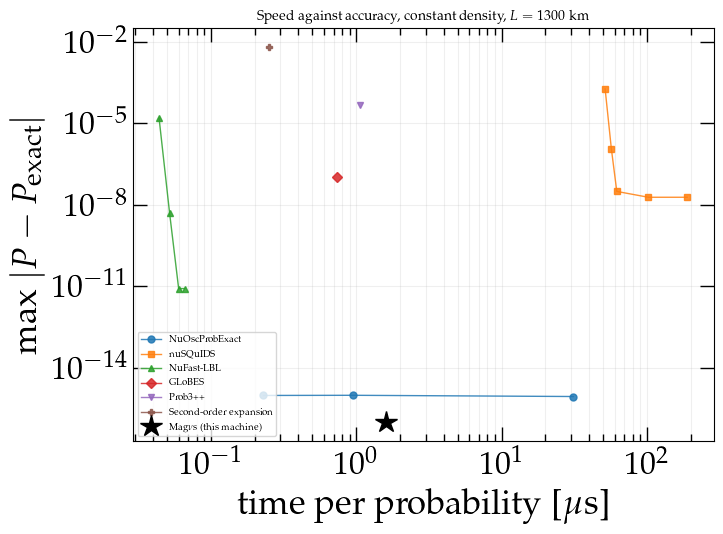

In [14]:
fig, ax = plt.subplots(figsize=(7.4, 5.0))

FLOOR = 1.0e-16          # machine precision; several codes sit on it
markers = {'NuOscProbExact': 'o', 'nuSQuIDS': 's', 'NuFast-LBL': '^',
           'GLoBES': 'D', 'Prob3++': 'v', 'Second-order expansion': 'P'}
for i, series in enumerate(EXTERNAL['series']):
    us = [p['us_per_probability'] for p in series['points']]
    err = [max(p['max_abs_error'], FLOOR) for p in series['points']]
    ax.plot(us, err, marker=markers.get(series['name'], 'o'), ms=5,
            color='C%d' % i, lw=1.0, alpha=0.85, label=series['name'])

P_m, t_m = best_of(lambda: np.asarray(oscprob.osc_prob_3nu_matter_constant_density(
    E, BASELINE, RHO, **OSC, density_matter_is_in_g_per_cm3=True,
    nu_i=gd.NUMU, nu_f=gd.NUE)))
ax.plot([1.0e6*t_m/N_E], [max(float(np.max(np.abs(P_m - reference))), FLOOR)],
        marker='*', ms=16, color='k', ls='none', label=r'Mag$\nu$s (this machine)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'time per probability [$\mu$s]')
ax.set_ylabel(r'max $|P - P_{\rm exact}|$')
ax.set_title(r'Speed against accuracy, constant density, $L = 1300$ km', fontsize=10)
ax.grid(True, which='both', alpha=0.2)
ax.legend(fontsize=7, loc='lower left')

Read the vertical axis first. Three codes reach machine precision -- Mag$\nu$s,
NuOscProbExact, and NuFast at three Newton steps -- and the rest trade accuracy for speed by
between four and thirteen orders of magnitude. The second-order expansion is the extreme:
$6\times10^{-3}$, which is the size of the effects notebooks 15 and 17 are about, for a
quarter of a microsecond.

Read the horizontal axis only *within* a curve. nuSQuIDS tightening its tolerance from
$10^{-4}$ to $10^{-8}$ costs 20% and buys four orders of magnitude; past that it costs three
times as much and buys nothing, having hit its own floor. That statement is about nuSQuIDS
alone and survives a change of machine. "Code A is faster than code B" does not.

## Summary

| | |
|---|---|
| constant density, exactness | Mag$\nu$s and NuOscProbExact both $\sim10^{-16}$ |
| constant density, speed | **comparable batched**, both ~1 µs/probability; both an order of magnitude slower called one energy at a time |
| single point, constant density | the closed form by ~1.7×, almost all of it wrapper parameter resolution |
| PREM, 3ν, cost per call | NuOscProbExact by ~20× |
| PREM, 3ν, accuracy reachable | Mag$\nu$s to $3\times10^{-10}$; the closed form stalls near $6\times10^{-5}$ |
| PREM, 3+1 with an eV splitting | NuOscProbExact by ~10$^3$, and Mag$\nu$s *warns* |
| vacuum, nuSQuIDS vs exact | $\sim10^{-8}$ -- solver is fine |
| matter, nuSQuIDS vs Mag$\nu$s | a **1% $V_{\rm CC}$ convention difference**, not accuracy |

The comparison worth making is not "which code is fastest" but "which code solves my problem",
and the table above does not have a winner in it -- it has a boundary. A **piecewise-constant**
profile is what a closed form is for, and the larger the accumulated phase the more decisively
so: the 3+1 row is the clearest result in this notebook and it is not in Mag$\nu$s's favour.
Below about $10^{-4}$ on PREM the closed form is also the cheaper way to get there.

What Mag$\nu$s buys is everything that is not that: accuracy past where a piecewise-constant
discretisation stalls, an arbitrary varying profile, a custom Hamiltonian, a BSM term nobody has
diagonalised. Where a closed form exists and the phase is large, use it.

And before comparing any two codes' numbers: **check that they agree in vacuum first.** If they
do not, the disagreement is in the solvers. If they do and they disagree in matter, it is in
the conventions, and no amount of tolerance will close it.

---

**Previous:** [Performance](24_magnus_performance.ipynb)  
**Next:** [Fourteen years of NuFIT](26_magnus_nufit_evolution.ipynb) --- how the parameter likelihood, not just the best fit, moves the probability  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)